# 🎯 Bayesian Optimization

In this notebook, we use **Bayesian Optimization** to tune the **learning rate** of a machine learning model so that it achieves the highest possible validation accuracy.

**Why does this matter?** ⏳ Each training run can cost hours of GPU time, so blindly grid-searching or guessing hyperparameters is wasteful. Bayesian Optimization finds a near-optimal setting in just a handful of evaluations: which is exactly why it underpins real-world hyperparameter tuning, experiment design, and any expensive black-box optimization problem.

## 🧩 Problem Setting

Our goal: pick the learning rate that **maximizes validation accuracy**. 🏆

📈 There is an unknown objective function $f(x)$ that gives the expected validation accuracy for a given learning rate, where $x = \log_{10}(\text{learning rate})$.

📏 We work in **log-space** because learning rates are naturally compared on a multiplicative scale (e.g. $10^{-4}$ vs $10^{-3}$). So here $x$ ranges over $[-5, -1]$, i.e. learning rates from $10^{-5}$ to $10^{-1}$.

### ⚠️ The challenge

- 💸 **Few evaluations.** Each observation is a full training run (potentially hours of GPU time), so we can only try a small number of learning rates.
- 🎲 **Noisy observations.** Even training twice with the same learning rate gives slightly different accuracy, due to random weight initialization, data shuffling, and other sources of randomness.

### 🌊 Our key assumption: smoothness

We don't know the exact form of the objective function, but we assume it is **smooth**: similar learning rates should produce similar outcomes.

This is an important assumption: it says that training with a learning rate of $10^{-3}$ and $1.1\times10^{-3}$ is likely to yield very similar validation accuracy. 🤝

In [1]:
# @title: Repo setup {display-mode: "form"}
import os, sys

REPO_OWNER = "eth-fdd-fs26"
REPO_NAME  = "FDD-WE1-private" # "FDD-WE1-public"
BRANCH_NAME = "main" # "active-learning"

def _in_colab():
    try:
        import google.colab
        return True
    except Exception:
        return False

if _in_colab():
    token = ""
    try:                                  # private repo (testing): read token from Secrets
        from google.colab import userdata
        token = userdata.get("GITHUB_TOKEN") or ""
    except Exception:                     # public repo (students): no token needed
        token = ""
    auth = f"{token}@" if token else ""
    url = f"https://{auth}github.com/{REPO_OWNER}/{REPO_NAME}.git"
    if not os.path.isdir(REPO_NAME):
        print("Cloning the exercise repo…")
        !git clone -q -b "$BRANCH_NAME" "$url"
    else:                                 # already cloned earlier — refresh to the latest version
        print("Updating the exercise repo to the latest version…")
        !git -C "$REPO_NAME" pull -q "$url" || echo "  (could not pull — using the existing copy)"
    os.chdir(f'/content/{REPO_NAME}')

In [2]:
# @title Imports {display-mode: "form"}

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# Auto-reload edited modules (e.g. utils.py) without restarting the kernel
# %load_ext autoreload
# %autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from bo_utils import get_objective, sample_from_objective, plot_grid, get_viz, plot_gif, plot_regrets

# suppress convergence warnings
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [3]:
# We search the learning rate in log10-space: x in [-5, -1] means LR in [1e-5, 1e-1]
DOMAIN = [-5, -1]

## 👀 Visualizing the Unknown Objective

Let's look at some potential shapes this objective function could take. Since we model it with a Gaussian Process, we can sample from the prior to see what kind of accuracy-vs-learning-rate curves our model considers plausible.

In [ ]:
# @title Visualize the potential shape of the objective {display-mode: "form"}
plot_grid()

## 🛠️ Setup

We initialize our Gaussian Process model with an RBF kernel. This kernel controls the "smoothness" of the function.

> 📝 **Note on kernel selection.** The kernel is one of the most important modeling choices we make. It encodes our assumptions about the shape of the function we're trying to predict, and different kernels lead to very different predicted shapes. If reality is very different from the model we assume, the optimization will fail: the GP will make poor predictions and the search can be misled. (Later in this notebook we see this concretely by varying the RBF `length_scale`.)

In [ ]:
# Initialize the model
kernel = RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9, normalize_y=True)

### 🧠 Quick check: which point does UCB pick?

Before we implement UCB, let's build intuition. The plot below shows a GP posterior after 10 observations (red **&times;**), with the shaded band showing $\mu(x) \pm \beta\,\sigma(x)$. Four candidate learning rates are marked **A-D** on the x-axis.

Using $UCB(x) = \mu(x) + \beta\,\sigma(x)$, which candidate would the acquisition function query next? Read the mean and the top of the band at each candidate before answering.

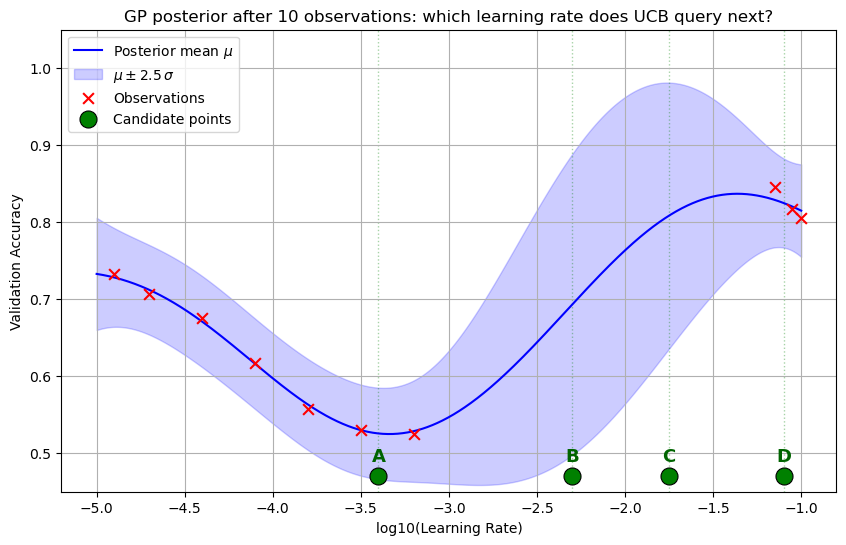

In [6]:
# @title Which point does UCB pick? {display-mode: "form"}
from bo_utils import plot_ucb_exercise, ucb_quiz
plot_ucb_exercise()

In [ ]:
# @title Submit your answer {display-mode: "form"}
ucb_quiz()

### 🎯 Fill `get_next_query` to query the the learning our agent will pick next:

In [ ]:

def get_next_query(model, domain: tuple, beta: float) -> float:
    """
    Select the next input point to evaluate using the Upper Confidence Bound (UCB) acquisition function.

    Args:
        model:  Trained model that provides predictions and uncertainty via `predict`.
        domain: Lower and upper bounds of the search space.
        beta:   Exploration parameter. Higher values favor exploring uncertain regions,
                lower values favor exploiting high predicted values.

    Returns:
        float: The next input value to query, corresponding to the maximum UCB.
    """
    
    X_grid = np.linspace(domain[0], domain[1], 1000).reshape(-1, 1)
    
    # 🎯 Get mean (mu) and standard deviation (sigma) predictions from the GP model
    # Hint: https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html#sklearn.gaussian_process.GaussianProcessRegressor.predict
    mu, sigma = ... # 🎯
    
    # 🎯Calculate the Upper Confidence Bound (UCB) for each point in the grid
    # Recall the formula from above: UCB(x) = mu(x) + beta * sigma(x)
    # Hint: no need to use a for-loop; you can compute UCB for all points in the grid at once using vectorized operations
    ucb = ... # 🎯
    
    # return the point with the highest UCB
    idx = np.argmax(ucb)
    return X_grid[idx][0]

In [ ]:
# @title Test your implementation {display-mode: "form"}
from bo_utils import test_get_next_query
test_get_next_query(get_next_query)

## 🔁🎯 Optimization Loop

Now we run the loop: pick a point, observe the value, update the model.

In [ ]:
# Get the true objective (hidden from the agent in a real scenario)
objective = get_objective(random_state=42)

# Initialize the model
kernel = RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)


def optimize(
    n_queries=25,
    beta=2.5,
    model=model,
    show=True,
    title_prefix="",
    figsize=(10, 6),
    ):
    """
    Run Bayesian Optimization for a fixed number of queries.

    Args:
        n_queries (int): Number of times the objective function is evaluated.
        beta (float): Exploration parameter for the UCB acquisition function.
        model: model used to approximate the objective function.
        show (bool): If True, build and display the run's GIF. Set to False when the
            frames will be combined with other runs into a single GIF.
        title_prefix (str): Prefix added to each frame title (e.g. the kernel label).
        figsize (tuple): Per-frame figure size, forwarded to get_viz.

    Returns:
        tuple:
            X_obs (list): List of queried input values.
            y_obs (list): List of observed (noisy) objective values.
            images_buff (list): List of PIL frames, one per iteration.
    """

    # 🎯 Store observations, create 2 empty lists for X_obs and y_obs values, they will be the "history" of the optimization process
    # Recall that our model is a GP and GP models are updated with new observations after each query, updating our belief about the objective function every time we get a new observation.
    ... # 🎯
    ... # 🎯

    # Setup directory for saving plots (don't worry about this part, it's just for visualization)
    images_buff = []

    for i in range(n_queries):

        # 1. Choose next point
        if len(X_obs) == 0:
            # Initial random point (if no observations yet, we sample a random point from the domain)
            next_x = np.random.uniform(DOMAIN[0], DOMAIN[1])
        else:
            # 🎯 Choose next point using the UCB acquisition function we implemented above.
            next_x = ... # 🎯


        # 2. Observe noisy value (this would correspond to training a model with the chosen hyperparameter and evaluating its performance on a validation set)
        next_y = sample_from_objective(next_x, objective)

        # 🎯 3. Update records: update X_obs and y_obs with the new observation we just made
        X_obs.append(...) # 🎯
        y_obs.append(...) # 🎯


        # 🎯 Fit model on current data (including new point) for plotting
        # Hint: use np.array(X_obs).reshape(-1, 1) to convert X_obs into a array of this format: [[x1], [x2], ...]
        # Hint: https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html#sklearn.gaussian_process.GaussianProcessRegressor.fit
        model.fit(..., ...) # 🎯


        # Create visualization for this iteration (ignore this part)
        title = f"{title_prefix} · Iteration {i+1}" if title_prefix else f"Iteration {i+1}"
        img = get_viz(model, X_obs, y_obs, beta=beta, objective=objective, title=title, figsize=figsize)
        images_buff.append(img)

    # Create a GIF, you can ignore this part
    if show:
        # Create GIF
        gif_path = "optimization_process.gif"
        plot_gif(images_buff, output_path=gif_path, duration=1200)

        # Display GIF
        from IPython.display import Image, display
        display(Image(filename=gif_path))

    return X_obs, y_obs, images_buff


# Run Bayesian Optimization
_, y_obs, _ = optimize()

# 📉 Analyzing Regret

Regret at time $t$ is defined as:

$$
r_t = f(x^*) - f(x_t)
$$

where $x^*$ is the input that achieves the optimal value of the objective function (ie: the unknown best theoretical learning rate, in our setting), and $x_t$ is the point chosen at time $t$.

The cumulative regret over $T$ steps is defined as:

$$
R_T = \sum_{t=1}^T r_t
$$

In this notebook, we compute regret with respect to the global maximum of the objective function over the domain.
This choice is made for teaching and visualization purposes only, since it allows us to clearly assess how well the optimization process performs over time.

In real-world applications, the true global maximum is unknown, and regret cannot be computed exactly in this way.

In [ ]:
def get_cumulative_regret(objective, observations):
    """
    Compute the cumulative regret over a sequence of observations.

    Args:
        objective (tuple): Tuple containing the true objective definition.
        observations (list or array): Observed (noisy) objective values
                                      collected during optimization.

    Returns:
        np.ndarray: Cumulative regret at each iteration.
    """
    
    best_value = np.max(objective[1])
    
    regrets = [best_value - y for y in observations]
    
    return np.cumsum(regrets)


regrets = get_cumulative_regret(objective, y_obs)
plot_regrets(objective, regrets)


# 🎛️ Hyperparameter optimization for Bayesian Optimization

The way we choose the kernel, kernel parameters and values such as beta greatly affect the result of the optimization process.

## 📐 Analysis of the impact of length scale on the optimization process

The RBF `length_scale` controls how smooth the model assumes the objective to be. To see its effect, the next cell runs the *same* optimization problem with three different length scales and stitches the runs into a **single side-by-side animation**.

As it plays, watch each panel and ask: does the search actually zero in on the global maximum, or does it get misled?

In [ ]:
# Create a new objective (shared across all runs so the panels are directly comparable)
objective = get_objective(random_state=500)

from bo_utils import compare_length_scales

# We test out different length scales (note that thanks to Object Oriented Programming, we can easily swap out the kernel used by the model without changing any other code!)
kernels = [
    # balanced: length scale matched to the objective
    RBF(length_scale=1.0, length_scale_bounds="fixed") +
    WhiteKernel(noise_level=0.1, noise_level_bounds="fixed"),

    # too smooth: large length scale underfits the objective
    RBF(length_scale=10.0, length_scale_bounds="fixed") +
    WhiteKernel(noise_level=0.1, noise_level_bounds="fixed"),

    # too wiggly: tiny length scale overfits the noise
    RBF(length_scale=0.01, length_scale_bounds="fixed") +
    WhiteKernel(noise_level=0.1, noise_level_bounds="fixed"),
]
labels = ["ℓ = 1.0 (balanced)", "ℓ = 10.0 (too smooth)", "ℓ = 0.01 (too wiggly)"]

compare_length_scales(optimize, kernels, labels)

The single animation above shows all three length scales side-by-side, so we can compare how the choice of kernel shapes Bayesian optimization on the same problem.

- **Left panel (ℓ = 1.0)**: the length scale is just right, so the model captures the true shape and the search successfully finds the global maximum.
- **Middle panel (ℓ = 10.0)**: the length scale is too large, so the model is over-smoothed and underfits. It never resolves the peak and the optimization misses the global maximum.
- **Right panel (ℓ = 0.01)**: the length scale is too small, so the model is overly wiggly and overfits the noise. It chases spurious bumps and again fails to find the global maximum.

This shows that picking the right length scale is a balance: too large and you miss the real structure, too small and you get misled by noise.

# ⚖️ Analysis of the impact of beta in the optimization process

Before running the next cell, take a moment to think about these questions:

Recall our UCB sampling strategy:
$$UCB(x) = \mu(x) + \beta \cdot \sigma(x)$$

1. What do you think will happen if we set $\beta = 0$?
2. What do you think will happen if $\beta$ is very large?
3. Based on your answers, what does $\beta$ control visually in the optimization process?

Now, let's run the next cell, which sweeps four values of $\beta$ and stitches them into a **single side-by-side animation** so we can compare how each level of exploration behaves on the same problem.

In [ ]:
# Create a new objective (shared across all runs so the panels are directly comparable)
objective = get_objective(random_state=500)

from bo_utils import compare_betas

# We test out different exploration parameters
betas = [0.3, 1, 2.996, 10]

compare_betas(optimize, betas)

As we can see from the panels, $\beta$ controls how much we "inflate" the model's uncertainty.

- **Two left panels (low $\beta$)**: the model doesn't explore enough. This can lead to settling for suboptimal solutions or taking longer to find the optimal solution.
- **Two right panels (high $\beta$)**: the model explores much more. By being more "optimistic" about uncertain points, it tests many possibilities before zeroing in on the optimal solution.

## 🎉 Congratulations!

You've built a full Bayesian optimization loop from scratch: a GP surrogate, a UCB acquisition function, the optimization loop, regret analysis, and a feel for how the kernel's length scale and the exploration parameter $\beta$ shape the search.

Here we worked in a single dimension (the learning rate) to keep everything easy to visualize, but in reality we run all of this in **many dimensions** at once, tuning several hyperparameters jointly.

You're now ready for the **Safe Bayesian Optimization** notebook. The only new trick there: we model not just the objective but also a **safety constraint**, each with its own GP. We stay **optimistic about the objective** (explore where it might be high) while being **pessimistic about safety** (only query points we're confident are safe).

## 💬 Questions to ponder

Some open-ended prompts to deepen your intuition. There's no single right answer, so treat them as conversation starters.

1. **Uncertainty as the acquisition function.** We saw that the UCB formula $\mu(x) + \beta\,\sigma(x)$ drives the next query. What happens if we drop the mean and query purely the point of **highest posterior variance** $\sigma(x)$ at each step? Where would the search spend its budget, and in which situations would this be exactly what we want (hint: think about *learning the whole function* vs. *finding its maximum*)?

2. **Pure exploitation.** The opposite extreme: query the point of highest posterior **mean** $\mu(x)$ only ($\beta = 0$). What failure mode does this create, and how does it relate to the $\beta$ sweep you just ran?

3. **When does BO break down?** Recall the note on kernel selection and the length-scale experiment. What kinds of objective functions (e.g. discontinuous, extremely wiggly, high-dimensional, or very cheap to evaluate) would make Bayesian optimization a *poor* choice compared to simpler alternatives like random or grid search?

Feel free to think about these on your own, jot down your hypotheses, and reach out to a TA to discuss — or simply carry your curiosity straight into the next notebook. 🚀
